In [ ]:
# Loss Functions and Backpropagations 

In [ ]:
# Loss Function:
    # -Quantify the difference between the predicted output of a model and the actual target value.
    # -Guide the training process by providing metrics to minimize during optimization.

    # Role in Neural Netork:
        # -Error Measurement: Evaluate the accuracy of predictions.
    # Feedback for optimization: Provides gradient for weight updates during backpropagation.

# Common types of Loss function:
    # Mean Squared error(MSE):
        # -Used for regression problems.
        # -Calculates the average of the squares of the differences between predicted and actual values.
        # -Formula: MSE = (1/n) * Σ(y_pred - y_true)^2
        # -penalizes larger errors heavily than smaller ones.

    # Cross-Entropy Loss:
        # -Used for classification problems.
        # -Measures the difference between two probability distributions: the predicted probabilities and the actual class labels.
        # -Formula: Cross-Entropy = -Σ(y_true * log(y_pred))
        # -Encourages the model to assign higher probabilities to the correct classes.


In [ ]:
# Backpropagation:
    # -process of computing gradients for each weight and bias in a neural network, enabling optimization algorithms(like gradient descent) to update the parameters and minimize the loss function.

    # Steps in Backpropagation:
        # Forward Pass: Input data is passed through the network to compute the predicted output and the loss.
        # Backward Pass: The loss is propagated backward through the network, calculating the gradients of the loss with respect to each weight and bias using the chain rule of calculus.
        # Parameter Update: The computed gradients are used to update the weights and biases, typically using an optimization algorithm like gradient descent.
        # weight upadate means parameter update, which is the process of adjusting the weights and biases of a neural network based on the computed gradients during backpropagation. The goal is to minimize the loss function by iteratively updating the parameters in the direction that reduces the error between predicted and actual values.

    # Importance of Backpropagation:
        # Efficient Gradient Computation: Backpropagation allows for the efficient calculation of gradients for all parameters in the network, regardless of its depth.
        # Enables Deep Learning: Backpropagation is essential for training deep neural networks, as it allows for the optimization of multiple layers of parameters.
        # Foundation for Optimization: Backpropagation provides the necessary gradients for optimization algorithms to update the parameters and improve the model's performance over time.

# Key concepts:
    # Gradient: the rate of change of the loss with respect to a parameter
    # Gradient Descent: an optimization algorithm that updates parameters in the direction of the negative gradient to minimize the loss function.
    # Learning Rate: a hyperparameter that controls the step size of parameter updates during optimization.

In [ ]:
# exercise:
# Objective:
    # Implement basic loss function, calculate gradient manually, and visua;ize the effects of different loss functions on a simple dataset.

Mean Squared Error Loss: 0.024999999999999994
Binary Cross-Entropy Loss: 0.164252033486018
MSE Gradient: [ 0.05 -0.05 -0.1   0.1 ]
Binary Cross-Entropy Gradient: [-1.11111111  1.11111111  1.25       -1.25      ]


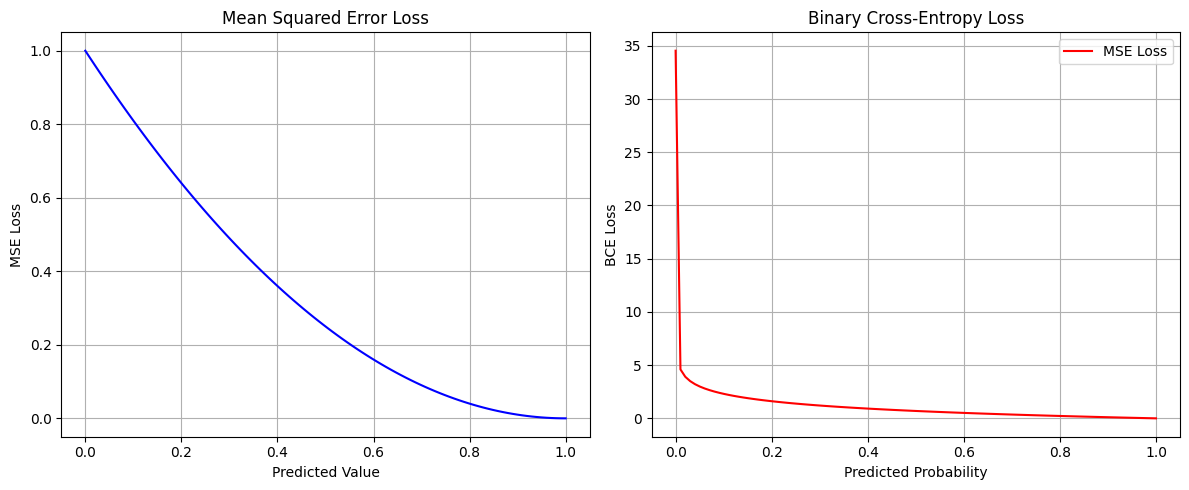

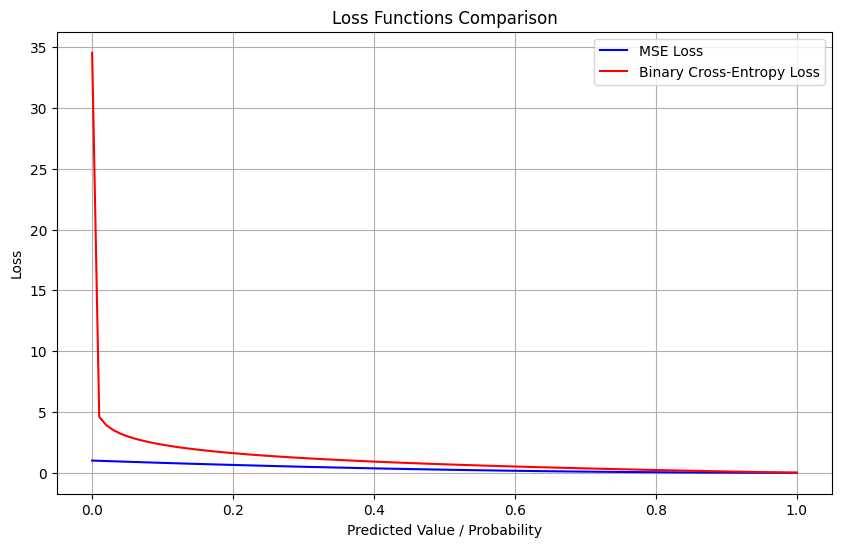

In [11]:
import numpy as np

# Mean Squared Error (MSE) Loss Function
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Binary cross-entropy(BCE) loss function
def binary_cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # Avoid log(0   or log(1))
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1 - y_pred))

# Example data
y_true = np.array([0, 1, 1, 0])  # Actual labels
y_pred = np.array([0.1, 0.9, 0.8, 0.2])  # Predicted values for MSE and probabilities for BCE

# calculate loss
mse = mse_loss(y_true, y_pred)
bce = binary_cross_entropy_loss(y_true, y_pred)
print(f'Mean Squared Error Loss: {mse}')
print(f'Binary Cross-Entropy Loss: {bce}')

# Derivate of MSE loss
def mse_gradient(y_true, y_pred):
    return 2 * (y_pred - y_true) / len(y_true)

# Derivative of BCE loss
def binary_cross_entropy_gradient(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # Avoid division by zero
    return (y_true - y_pred) / (y_pred * (1 - y_pred))

# Calculate gradients
mse_grad = mse_gradient(y_true, y_pred)
bce_grad = binary_cross_entropy_gradient(y_true, y_pred)
print(f'MSE Gradient: {mse_grad}')
print(f'Binary Cross-Entropy Gradient: {bce_grad}')

# Visualization of Loss Functions
import matplotlib.pyplot as plt


# Define predictions and true labels for visualization
predictions = np.linspace(0, 1, 100)
true_label = 1  # Assuming the true label is 1 for visualization

# compute losses
mse_losses = [(true_label - pred)**2 for pred in predictions]
bce_losses = [-true_label * np.log(max(pred, 1e-15)) - (1 - true_label) * np.log(max(1 - pred, 1e-15)) for pred in predictions]

# Plot MSE Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(predictions, mse_losses, color='blue')
plt.title('Mean Squared Error Loss')
plt.xlabel('Predicted Value')
plt.ylabel('MSE Loss')
plt.grid()

# Plot Binary Cross-Entropy Loss
plt.subplot(1, 2, 2)
plt.plot(predictions, bce_losses, color='red')
plt.title('Binary Cross-Entropy Loss')
plt.xlabel('Predicted Probability')
plt.ylabel('BCE Loss')
plt.tight_layout()

plt.legend(['MSE Loss', 'BCE Loss'])
plt.grid()
plt.show()

#  or

plt.figure(figsize=(10, 6))
plt.plot(predictions, mse_losses, label='MSE Loss', color='blue')
plt.plot(predictions, bce_losses, label='Binary Cross-Entropy Loss', color='red')
plt.title('Loss Functions Comparison')
plt.xlabel('Predicted Value / Probability')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


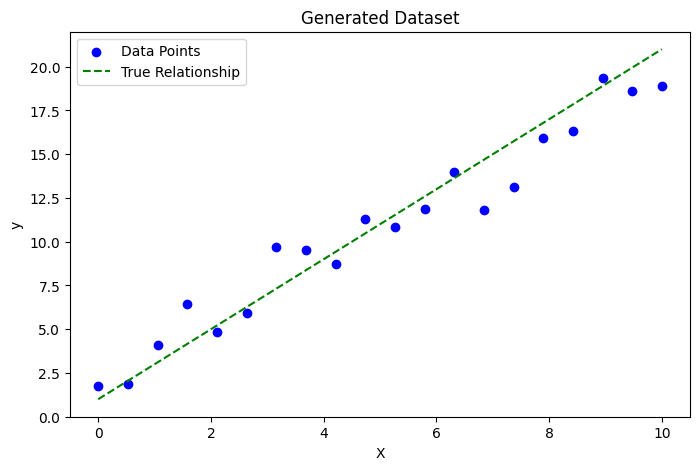

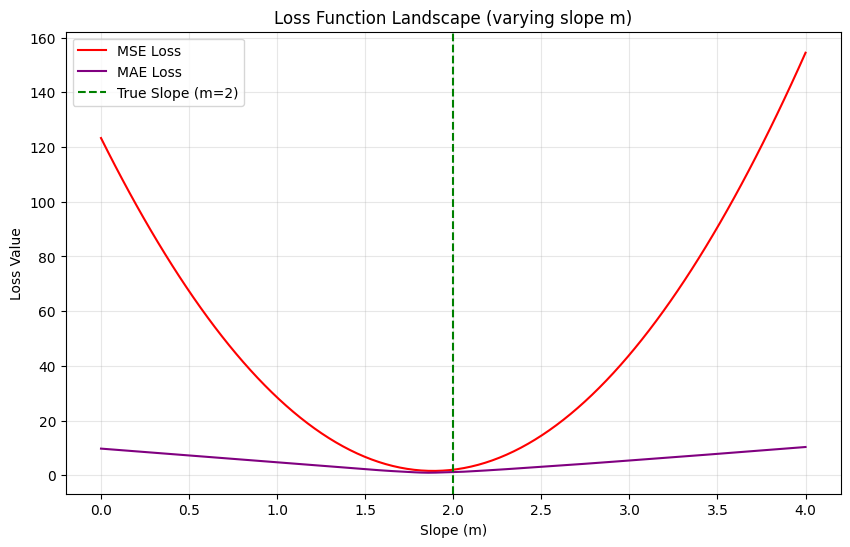


--- Starting Gradient Descent ---
Epoch 0: Loss=143.7710, m=1.3905, b=0.2149
Epoch 100: Loss=1.5551, m=1.8776, b=1.0662
Epoch 200: Loss=1.3419, m=1.8114, b=1.5160
Epoch 300: Loss=1.2679, m=1.7723, b=1.7811
Epoch 400: Loss=1.2421, m=1.7493, b=1.9374
Epoch 500: Loss=1.2332, m=1.7357, b=2.0295
Epoch 600: Loss=1.2301, m=1.7277, b=2.0839
Epoch 700: Loss=1.2290, m=1.7230, b=2.1159
Epoch 800: Loss=1.2286, m=1.7202, b=2.1347
Epoch 900: Loss=1.2285, m=1.7186, b=2.1459

Final Parameters: m=1.7176, b=2.1524
True Parameters: m=2, b=1


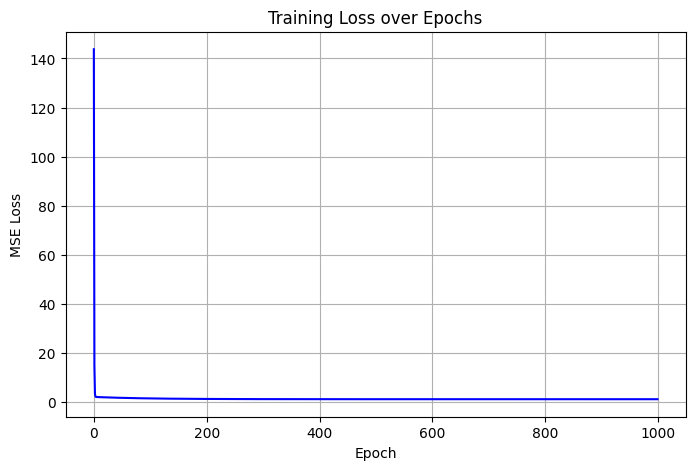

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Objective: Implement basic loss function, calculate gradient manually, 
# and visualize the effects of different loss functions on a simple dataset.

# 1. Generate a simple dataset
# Let's create data that follows a linear relationship y = 2x + 1 with some noise
np.random.seed(42)
X = np.linspace(0, 10, 20)
true_slope = 2
true_intercept = 1
noise = np.random.normal(0, 1.5, size=len(X)) # Add some noise
y_true = true_slope * X + true_intercept + noise

# Visualize the dataset
plt.figure(figsize=(8, 5))
plt.scatter(X, y_true, color='blue', label='Data Points')
plt.plot(X, true_slope * X + true_intercept, color='green', linestyle='--', label='True Relationship')
plt.title('Generated Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# 2. Implement Loss Functions
def mean_squared_error(y_true, y_pred):
    """Calculates Mean Squared Error (MSE)"""
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    """Calculates Mean Absolute Error (MAE)"""
    return np.mean(np.abs(y_true - y_pred))

# 3. Calculate Gradient Manually
# We will assume a simple linear model y = mx + b
# We need partial derivatives of MSE with respect to m (slope) and b (intercept)

def predict(X, m, b):
    return m * X + b

def calculate_gradients(X, y_true, y_pred):
    """
    Calculates gradients of MSE loss with respect to m and b.
    MSE = (1/n) * Σ(y_true - (mx + b))^2
    d(MSE)/dm = (-2/n) * Σ(x * (y_true - y_pred))
    d(MSE)/db = (-2/n) * Σ(y_true - y_pred)
    """
    n = len(y_true)
    # Gradient with respect to m
    dm = (-2/n) * np.sum(X * (y_true - y_pred))
    # Gradient with respect to b
    db = (-2/n) * np.sum(y_true - y_pred)
    return dm, db

# 4. Visualize the effects of different loss functions
# We will fix the intercept b to the true value (1) and vary the slope m
# to see how the loss changes.

m_values = np.linspace(0, 4, 100) # Range of slope values to test
mse_losses = []
mae_losses = []

b_fixed = 1 # Fixing intercept for visualization

for m in m_values:
    y_pred = predict(X, m, b_fixed)
    mse_losses.append(mean_squared_error(y_true, y_pred))
    mae_losses.append(mean_absolute_error(y_true, y_pred))

# Plotting Loss Landscapes
plt.figure(figsize=(10, 6))
plt.plot(m_values, mse_losses, label='MSE Loss', color='red')
plt.plot(m_values, mae_losses, label='MAE Loss', color='purple')
plt.axvline(x=true_slope, color='green', linestyle='--', label='True Slope (m=2)')
plt.title('Loss Function Landscape (varying slope m)')
plt.xlabel('Slope (m)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Perform Gradient Descent using manual gradients
print("\n--- Starting Gradient Descent ---")
m = 0.0 # Initial guess for slope
b = 0.0 # Initial guess for intercept
learning_rate = 0.01
epochs = 1000

loss_history = []

for i in range(epochs):
    y_pred = predict(X, m, b)
    loss = mean_squared_error(y_true, y_pred)
    loss_history.append(loss)
    
    dm, db = calculate_gradients(X, y_true, y_pred)
    
    # Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}: Loss={loss:.4f}, m={m:.4f}, b={b:.4f}")

print(f"\nFinal Parameters: m={m:.4f}, b={b:.4f}")
print(f"True Parameters: m={true_slope}, b={true_intercept}")

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()
